# System-Monitoring: Miss Detection & Aid Overwrites (F1 / F2 / F3)

OpenMATB transparency study -- the **system-monitoring** task, which is the only
task supported by the automation aid (~78% reliable). This notebook tests
**hypothesis H3** (selectivity directs attention to anomalies):

- **H3A -- detection of automation misses.** When the aid *skips* an event, the
  operator should catch it manually. Prediction: a higher proportion of
  aid-missed events are detected under the selective forms **F2/F3** than under
  the verbose always-on form **F1**.
- **H3B -- overwrites.** Prediction: operators are *less* likely to overwrite the
  aid when it was in fact right under **F2/F3** than under **F1**.

> **Status:** pipeline prepared on pilot data; re-run unchanged once P01-P20 are collected.

## How performance is measured (from the logs)

The aid handles an event when `automaticsolver` is on (it auto-solves after
`automaticsolverdelay`, ~1000 ms) and skips it when off. The sysmon log records
`signal_detection` (HIT/MISS/FA) but logs **HIT for both the aid's auto-solve and
a user key press**, so we use the `automaticsolver` state at each event to split:

- **Aid-skipped events (H3A):** HIT = the user detected the miss, MISS = not.
  We report the **detection rate** and the **reaction time** of detections.
- **Aid-handled events (H3B):** a HIT with `response_time` below the aid delay
  means the user pressed the key *before* the aid acted -- a pre-emptive
  **overwrite**. We also report **false alarms** (FA: a key press with no active
  target) as a second index of unnecessary intervention.

**Literature.** Detection of automation failures (hits/misses, reaction time) and
false alarms are the standard system-monitoring measures of MATB
(Comstock & Arnegard, 1992; Santiago-Espada et al., 2011). The expectation that
the *form* of transparency shapes anomaly detection and calibrated reliance on the
aid follows the agent-transparency / SAT literature (Chen et al., 2014;
Mercado et al., 2016; Stowers et al., 2017).


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table
from matb_analysis.discovery import find_study_sessions, DEFAULT_SESSIONS_DIR
from matb_analysis.validation import validate_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)


## 1. Load sessions and build the tidy metrics table

In [2]:
sessions = find_study_sessions()
print(f"Reading logs from: {DEFAULT_SESSIONS_DIR}")
print(f"Discovered {len(sessions)} study session(s).")
if not sessions:
    print("No logs yet. Copy the relevant OpenMATB session CSVs into")
    print("analysis/session_logs/ and re-run this notebook.")

table = build_metrics_table(sessions)
sysmon_cols = ["n_aid_miss_events", "n_detected", "detection_rate", "mean_detect_rt",
               "n_aid_handled_events", "n_overwrite", "overwrite_rate", "n_false_alarms"]
table[["participant", "form", "block"] + sysmon_cols]


Reading logs from: C:\Projects\HumanCenteredAI\analysis\session_logs
Discovered 1 study session(s).


,participant,form,block,n_aid_miss_events,n_detected,detection_rate,mean_detect_rt,n_aid_handled_events,n_overwrite,overwrite_rate,n_false_alarms
0,P02,F1,A,2,2,1.0,3000.0,7,0,0.0,0
1,P02,F3,B,2,0,0.0,NaN,7,0,0.0,3
2,P02,F2,C,2,2,1.0,3200.0,7,0,0.0,0


## 1b. Session validation

Each session is cross-checked against the study design (briefing vs. panel form,
panel vs. failed-gauge block, realised order vs. the participant's Latin-square
row). Resolve any `ok = False` row before trusting that session.

In [3]:
report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with issues.")
report


1 session(s) validated; 0 with issues.


,session_file,participant,kind,ok,n_blocks,realized,expected,issues
0,24_260530_151227.csv,P02,full,True,3,"[(F1, A), (F3, B), (F2, C)]","[(F1, A), (F3, B), (F2, C)]",


## 2. H3A -- Detection of automation misses by form

Among events the aid skipped (2 per block by design), the proportion the operator
caught (higher = better), and the reaction time of those detections.

In [4]:
h3a_cols = ["detection_rate", "mean_detect_rt", "n_detected", "n_aid_miss_events"]
h3a_desc = (table.groupby("form")[h3a_cols].agg(["mean", "median", "std"])
                 .reindex(FORM_ORDER))
h3a_desc


detection_rate            mean_detect_rt             n_detected         \
               mean median std           mean  median std       mean median   
form                                                                          
F1              1.0    1.0 NaN         3000.0  3000.0 NaN        2.0    2.0   
F2              1.0    1.0 NaN         3200.0  3200.0 NaN        2.0    2.0   
F3              0.0    0.0 NaN            NaN     NaN NaN        0.0    0.0   

         n_aid_miss_events             
     std              mean median std  
form                                   
F1   NaN               2.0    2.0 NaN  
F2   NaN               2.0    2.0 NaN  
F3   NaN               2.0    2.0 NaN

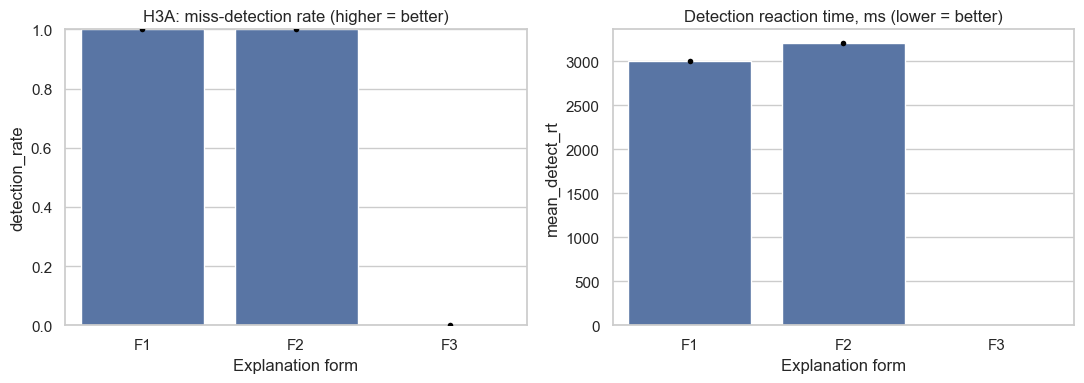

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(
    axes,
    ["detection_rate", "mean_detect_rt"],
    ["H3A: miss-detection rate (higher = better)",
     "Detection reaction time, ms (lower = better)"],
):
    sns.barplot(data=table, x="form", y=col, order=FORM_ORDER, errorbar="sd", ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER, color="black", size=4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Explanation form")
axes[0].set_ylim(0, 1)
fig.tight_layout()
fig.savefig(OUT / "h3a_detection_by_form.png", dpi=150)
plt.show()


## 3. H3B -- Overwrites of a correct aid by form

Pre-emptive overwrites (user beat the aid on an aid-handled event) and false
alarms (key press with no active target). Lower = better; H3B predicts F2/F3 < F1.

In [6]:
h3b_cols = ["overwrite_rate", "n_overwrite", "n_false_alarms", "n_aid_handled_events"]
h3b_desc = (table.groupby("form")[h3b_cols].agg(["mean", "median", "std"])
                 .reindex(FORM_ORDER))
h3b_desc


overwrite_rate            n_overwrite            n_false_alarms         \
               mean median std        mean median std           mean median   
form                                                                          
F1              0.0    0.0 NaN         0.0    0.0 NaN            0.0    0.0   
F2              0.0    0.0 NaN         0.0    0.0 NaN            0.0    0.0   
F3              0.0    0.0 NaN         0.0    0.0 NaN            3.0    3.0   

         n_aid_handled_events             
     std                 mean median std  
form                                      
F1   NaN                  7.0    7.0 NaN  
F2   NaN                  7.0    7.0 NaN  
F3   NaN                  7.0    7.0 NaN

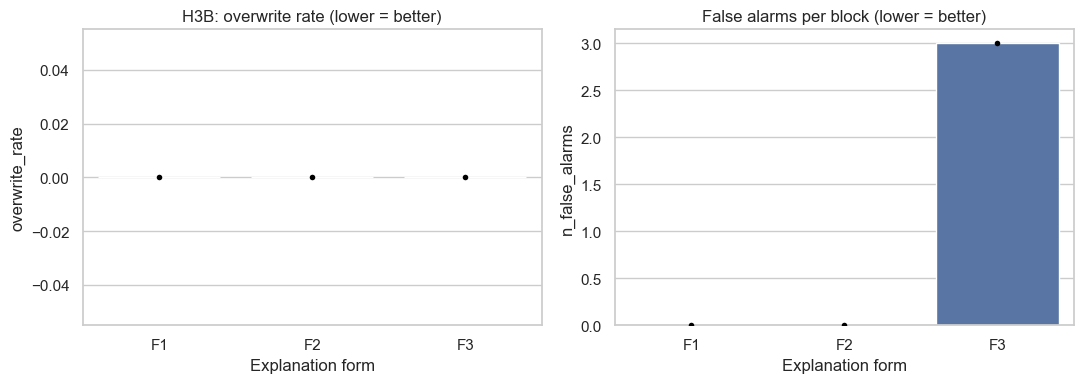

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(
    axes,
    ["overwrite_rate", "n_false_alarms"],
    ["H3B: overwrite rate (lower = better)",
     "False alarms per block (lower = better)"],
):
    sns.barplot(data=table, x="form", y=col, order=FORM_ORDER, errorbar="sd", ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER, color="black", size=4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Explanation form")
fig.tight_layout()
fig.savefig(OUT / "h3b_overwrite_by_form.png", dpi=150)
plt.show()


## 4. Summary table (H3)

One row per form. H3A predicts F2/F3 > F1 on detection rate; H3B predicts
F2/F3 < F1 on overwrite rate and false alarms.

In [8]:
summary = (table.groupby("form")[
              ["detection_rate", "mean_detect_rt", "overwrite_rate", "n_false_alarms"]]
              .mean().reindex(FORM_ORDER).round(2))
summary.to_csv(OUT / "h3_summary_by_form.csv")
summary


,detection_rate,mean_detect_rt,overwrite_rate,n_false_alarms
form,,,,
F1,1.0,3000.0,0.0,0.0
F2,1.0,3200.0,0.0,0.0
F3,0.0,NaN,0.0,3.0


## 5. Inferential tests -- to add when N is adequate

Deliberately omitted now (small pilot N; only ~2 aid-miss events per block, see
the slides' "Considerations & Limits"). When P01-P20 are collected, add
within-subject tests across the three forms (e.g. Friedman + Wilcoxon signed-rank,
or Cochran's Q on the per-event hit/miss), with assumptions stated. The tidy table
above is the input.
